# Optimization Comparisons
## By: Sandra Afrifa, Mussa Hassen, Andi Mellyn

Original dataset: https://www.kaggle.com/datasets/noeyislearning/framingham-heart-study

Framingham heart study dataset (over 4,240 records,16 columns) predict if patient has risk of future coronary heart disease (binary).



# Cost Functions and Model Setup
- We model the 10-year risk of coronary heart disease (TenYearCHD) using:

    1. **Logistic Regression**
    2. **Ridge Logistic Regression**

Let $X \in \mathbb{R}^{n \times d}$ be the feature matrix (standardized, with a bias column),
$y \in \{0,1\}^n$ the labels, and $w \in \mathbb{R}^d$ the parameter vector.

### Logistic regression model

The logistic function is:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

Predicted probability for sample $i$:

In code, we compute all $p_i$ at once via $p$ = sigmoid($X$ @ $w$)

$$
p_i = \sigma(x_i^\top w).
$$

The logistic loss is:

$$
J_{\text{log}}(w)
= -\frac{1}{n} \sum_{i=1}^n
\left[
y_i \log(p_i) + (1 - y_i)\log(1 - p_i)
\right].
$$

### Ridge logistic regression

We add an L2 penalty on all weights **except the bias term**:

$$
J_{\text{ridge}}(w)
= J_{\text{log}}(w)
+ \frac{\alpha}{2}
\|w_{\text{no-bias}}\|_2^2.
$$


- $\alpha$ controls the strength of regularization
- $w_{\text{no-bias}}$ is the vector of weights excluding the last (bias) term.
- In code, we refer to $w_{\text{no-bias}}$ as *feature_weights* $w=[:-1]$.


### Data cleaning

Omitted 2 columns, education and glucose, because they weren't important for predicting heart disease and had many NA values dropping the total columns to 14. Omitted rows with NA values dropping the total number of records to 4090.

\* *preserving all the data wasn't important for testing optimization algorithms*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import time

In [2]:
# model scripts
from models.logistic import logistic_loss, logistic_grad, logistic_hess, sigmoid
from models.logistic_ridge import logistic_ridge_loss, logistic_ridge_grad, logistic_ridge_hess

# algorithm scripts
from algorithms.gradient_descent import gradient_descent
from algorithms.adam import adam
from algorithms.newton import newton
from algorithms.bfgs import bfgs
from algorithms.conjugate_gradient import conjugate_gradient

In [3]:
# loading dataset

df = pd.read_csv("../data/framingham_cleaned.csv")
df.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,0


In [4]:
feature_cols = ["male", "age", "currentSmoker", "cigsPerDay", "BPMeds",
    "prevalentStroke", "prevalentHyp", "diabetes",
    "totChol", "sysBP", "diaBP", "BMI", "heartRate"]

target_col = "TenYearCHD"

In [5]:
# scale features, add a bias column
x_raw = df[feature_cols].to_numpy()
y = df[target_col].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_raw)

ones = np.ones((X_scaled.shape[0], 1))
X = np.hstack([X_scaled, ones])

print("X shape:", X.shape, "| y shape:", y.shape)

X shape: (4090, 14) | y shape: (4090,)


In [6]:
# data split into testing and training sets
# 20% test set
# random_state=42 is a reproducible split
# stratify=y ensures CHD proportion is balanced in each split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
print("Train X:", X_train.shape)
print("Train y:", y_train.shape)
print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Train X: (3272, 14)
Train y: (3272,)
Test X: (818, 14)
Test y: (818,)


In [8]:
# helper functions: probabilities, classes, accuracy

def predict_proba(X, w):
    """Predicted probabilities using logistic link."""
    return sigmoid(X @ w)

def predict_class(X, w, threshold=0.5):
    """Class predictions in (0,1)."""
    return (predict_proba(X, w) >= threshold).astype(int)

def accuracy_score(y_true, y_pred):
    """Classification accuracy."""
    return np.mean(y_true == y_pred)

## Optimization algorithms compared

We compare five optimization algorithms for minimizing the logistic and ridge logistic cost functions.

1. **Gradient (steepest) descent** (`gradient_descent`)<br>

   Updates:
   $$
   w_{k+1} = w_k - \eta \nabla J(w_k),
   $$
   where $\eta$ is a fixed learning rate. Uses only first-order information
   (the gradient). <br>
<br>


2. **Adam** (`adam`)<br>

   A first-order, adaptive method that keeps moving averages of the gradient
   and its elementwise square:
   - accumulates $m_k \approx \mathbb{E}[\nabla J(w_k)]$
   - accumulates $v_k \approx \mathbb{E}[\nabla J(w_k)^2]$
   and rescales the update coordinate-wise. Often converges faster and more
   robustly than standard gradient descent.<br>
<br>


3. **Newton's method** (`newton`)<br>

   Uses the Hessian to build a local quadratic approximation of the loss:
   $$
   w_{k+1} = w_k - H(w_k)^{-1} \nabla J(w_k).
   $$
   For convex problems, this gives (locally) quadratic convergence, often
   reaching the minimum in very few iterations, at the cost of computing and
   inverting $H(w_k)$.<br>
<br>


4. **BFGS (quasi-Newton)** (`bfgs`)<br>

   Builds an approximation $H_k^{-1}$ to the inverse Hessian using only
   gradients and updates it at each step:
   $$
   w_{k+1} = w_k - H_k^{-1} \nabla J(w_k).
   $$
   Achieves many of the benefits of Newton's method while avoiding explicit
   Hessian computation.<br>
<br>


5. **Nonlinear conjugate gradient** (`conjugate_gradient`)<br>

   Constructs search directions $p_k$ that are $A$-conjugate (for a quadratic
   loss) so that each new direction is "orthogonal" in the Hessian's geometry.
   This often leads to faster convergence than steepest descent, using only
   gradient information and no Hessian or Hessian approximations.

In [9]:
# sanity check run to test models and algorithms before looping them over the dataset (delete later)

d = X_train.shape[1]
w0 = np.zeros(d)

print("Initial logistic loss (train):", logistic_loss(w0, X_train, y_train))

w_gd, hist_gd = gradient_descent(w0=w0, loss_fn=logistic_loss, grad_fn=logistic_grad, X=X_train, y=y_train, lr=0.01, iters=300)

print("Final logistic loss (train):", hist_gd[-1])

y_train_pred = predict_class(X_train, w_gd)
y_test_pred  = predict_class(X_test, w_gd)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print("GD logistic — train accuracy:", train_acc)
print("GD logistic — test accuracy:", test_acc)

Initial logistic loss (train): 0.6931471785599453
Final logistic loss (train): 0.4766560553705203
GD logistic — train accuracy: 0.8505501222493888
GD logistic — test accuracy: 0.8545232273838631


In [10]:
# loop to run each optimization algorithm on each model
def run_optimizer(optimizer_name, model_name, X_train, y_train, X_test, y_test, alpha=1.0, iters=1000, lr=0.01, w0=None):
    """
    Runs a given optimizer on a given model -> logistic or ridge regression.
    Returns a dictionary of results.
    """
    # choose model-specific pieces
    if model_name == "logistic":
        loss_fn = logistic_loss
        grad_fn = logistic_grad
        hess_fn = logistic_hess

    elif model_name == "ridge":
        loss_fn = lambda w, X, y: logistic_ridge_loss(w, X, y, alpha=alpha)
        grad_fn = lambda w, X, y: logistic_ridge_grad(w, X, y, alpha=alpha)
        hess_fn = lambda w, X, y: logistic_ridge_hess(w, X, y, alpha=alpha)

    else:
        raise ValueError("Unknown model.")

    # initialize weights
    d = X_train.shape[1]
    # changing w0 to if statement allows different initial conditions
    if w0 is None:
        w0 = np.zeros(d)

    # time counter for optimizers
    start = time.perf_counter()

    # choose optimizer
    if optimizer_name == "gd":
        w, history = gradient_descent(w0=w0, loss_fn=loss_fn, grad_fn=grad_fn, X=X_train, y=y_train, iters=iters, lr=lr)

    elif optimizer_name == "adam":
        w, history = adam(w0=w0, loss_fn=loss_fn, grad_fn=grad_fn, X=X_train, y=y_train, iters=iters, lr=lr)

    elif optimizer_name == "newton":
        w, history = newton(w0=w0, loss_fn=loss_fn, grad_fn=grad_fn, hess_fn=hess_fn, X=X_train, y=y_train, iters=iters)

    elif optimizer_name == "bfgs":
        w, history = bfgs(w0=w0, loss_fn=loss_fn, grad_fn=grad_fn, X=X_train, y=y_train, iters=iters)

    elif optimizer_name == "cg":
        w, history = conjugate_gradient(w0=w0, loss_fn=loss_fn, grad_fn=grad_fn, X=X_train, y=y_train, iters=iters)

    else:
        raise ValueError("Unknown optimizer.")

    end = time.perf_counter()
    runtime = end - start   # runtime is in seconds

    # evaluate accuracy
    y_train_pred = predict_class(X_train, w)
    y_test_pred = predict_class(X_test, w)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    return {
        "Model": model_name,
        "Optimizer": optimizer_name,
        "Final_loss": history[-1],
        "Iterations": len(history),
        "Train_acc": train_acc,
        "Test_acc": test_acc,
        "Runtime": runtime,
        "History": history
    }

## Run all optimizer-model combinations

In [11]:
results = []
optimizers = ["gd", "adam", "newton", "bfgs", "cg"]
models = ["logistic", "ridge"]

for model_name in models:
    for opt_name in optimizers:
        print(f"Running {opt_name} on {model_name}...")
        res = run_optimizer(optimizer_name=opt_name, model_name=model_name, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,
                            alpha=1.0, iters=1000, lr=0.01)
        results.append(res)

results_df = pd.DataFrame(results)
results_df

Running gd on logistic...
Running adam on logistic...
Running newton on logistic...
Running bfgs on logistic...
Running cg on logistic...
Running gd on ridge...
Running adam on ridge...
Running newton on ridge...
Running bfgs on ridge...
Running cg on ridge...


,Model,Optimizer,Final_loss,Iterations,Train_acc,Test_acc,Runtime,History
0,logistic,gd,0.393087,1000,0.852384,0.856968,0.137563,"[0.6916914990364231, 0.6902447699937418, 0.688..."
1,logistic,adam,0.376119,1000,0.854218,0.855746,0.161581,"[0.685408036317412, 0.6784113025175069, 0.6720..."
2,logistic,newton,0.376119,6,0.854218,0.855746,0.001605,"[0.6931471785599453, 0.3984932730789584, 0.377..."
3,logistic,bfgs,0.376119,58,0.854218,0.855746,0.008997,"[0.6931471785599453, 0.569534416006646, 0.4027..."
4,logistic,cg,0.376119,354,0.854218,0.855746,0.050210,"[0.6931471785599453, 0.569534416006646, 0.5035..."
5,ridge,gd,0.420941,1000,0.850550,0.850856,0.139075,"[0.691692644396655, 0.6902515399379457, 0.6888..."
6,ridge,adam,0.413004,1000,0.850550,0.850856,0.145253,"[0.6860580356607273, 0.6807151037215401, 0.676..."
7,ridge,newton,0.413004,5,0.850550,0.850856,0.001377,"[0.6931471785599453, 0.42140595066842546, 0.41..."
8,ridge,bfgs,0.413004,9,0.850550,0.850856,0.001320,"[0.6931471785599453, 0.5809880183253068, 0.426..."
9,ridge,cg,0.413004,89,0.850550,0.850856,0.012329,"[0.6931471785599453, 0.5809880183253068, 0.517..."


In [12]:
# plot convergence
def plot_histories(results_df, model_name):
    plt.figure(figsize=(10, 8))

    subset = results_df[results_df["Model"] == model_name]

    for _, row in subset.iterrows():
        plt.plot(row["History"], label=row["Optimizer"])

    plt.xlabel("Iterations")
    plt.ylabel("Training loss")
    plt.title("Convergence curves for " + model_name)
    plt.legend()
    plt.show()


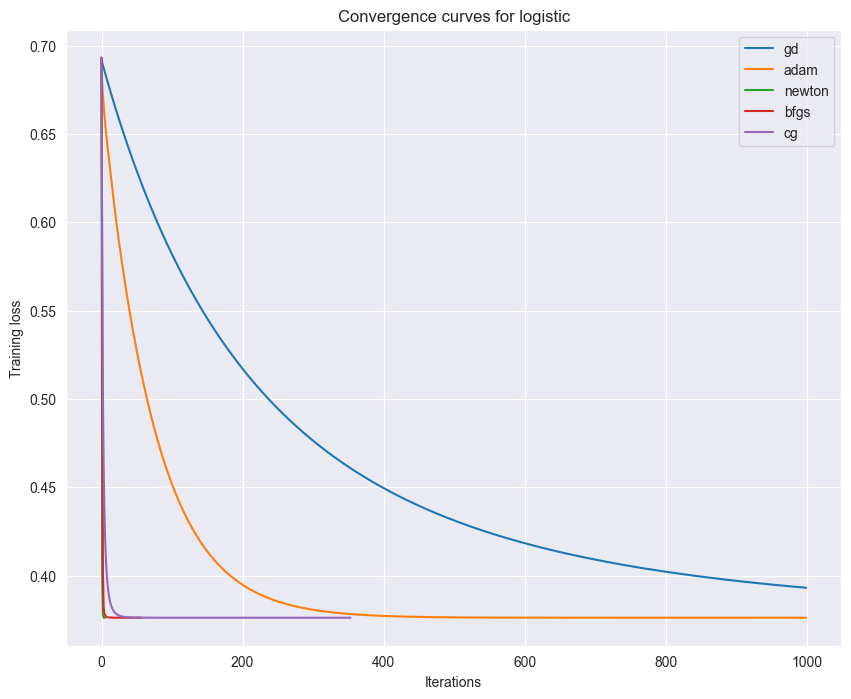

In [13]:
plot_histories(results_df, "logistic")

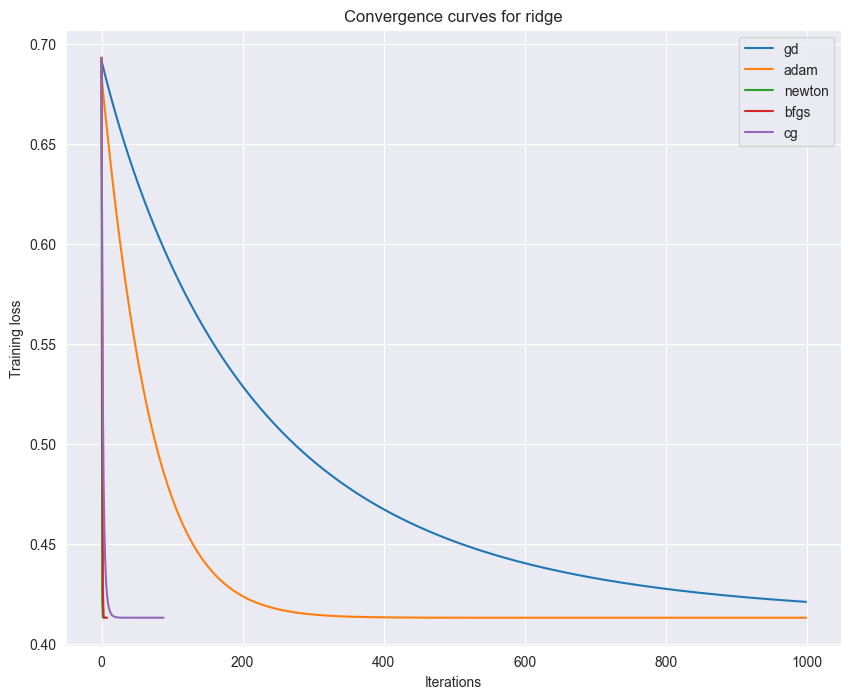

In [14]:
plot_histories(results_df, "ridge")

In [15]:
results_df.sort_values(["Test_acc", "Train_acc", "Optimizer"])

,Model,Optimizer,Final_loss,Iterations,Train_acc,Test_acc,Runtime,History
6,ridge,adam,0.413004,1000,0.850550,0.850856,0.145253,"[0.6860580356607273, 0.6807151037215401, 0.676..."
8,ridge,bfgs,0.413004,9,0.850550,0.850856,0.001320,"[0.6931471785599453, 0.5809880183253068, 0.426..."
9,ridge,cg,0.413004,89,0.850550,0.850856,0.012329,"[0.6931471785599453, 0.5809880183253068, 0.517..."
5,ridge,gd,0.420941,1000,0.850550,0.850856,0.139075,"[0.691692644396655, 0.6902515399379457, 0.6888..."
7,ridge,newton,0.413004,5,0.850550,0.850856,0.001377,"[0.6931471785599453, 0.42140595066842546, 0.41..."
1,logistic,adam,0.376119,1000,0.854218,0.855746,0.161581,"[0.685408036317412, 0.6784113025175069, 0.6720..."
3,logistic,bfgs,0.376119,58,0.854218,0.855746,0.008997,"[0.6931471785599453, 0.569534416006646, 0.4027..."
4,logistic,cg,0.376119,354,0.854218,0.855746,0.050210,"[0.6931471785599453, 0.569534416006646, 0.5035..."
2,logistic,newton,0.376119,6,0.854218,0.855746,0.001605,"[0.6931471785599453, 0.3984932730789584, 0.377..."
0,logistic,gd,0.393087,1000,0.852384,0.856968,0.137563,"[0.6916914990364231, 0.6902447699937418, 0.688..."


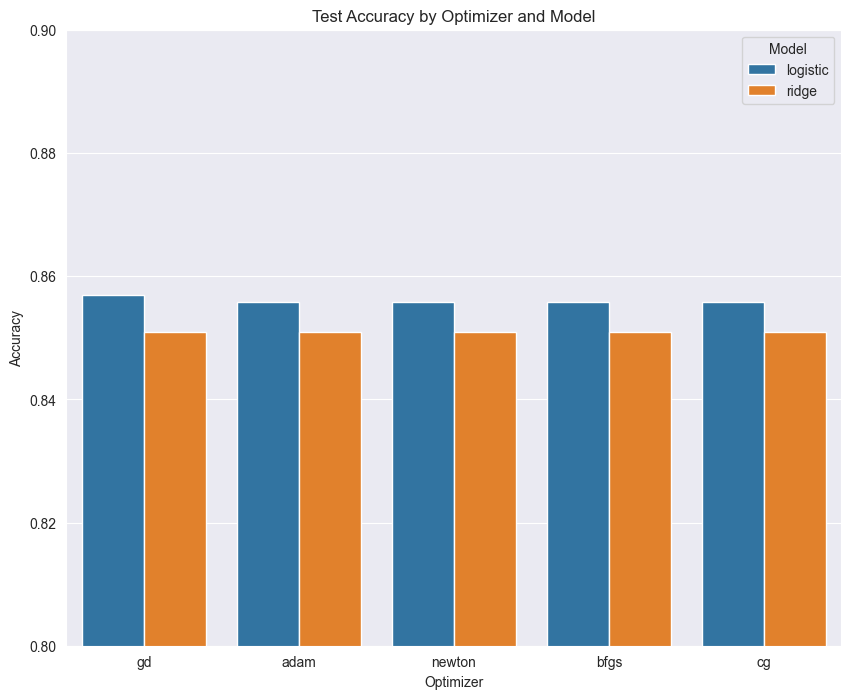

In [16]:
plt.figure(figsize=(10, 8))
sns.barplot(data=results_df, x="Optimizer", y="Test_acc", hue="Model")
plt.title("Test Accuracy by Optimizer and Model")
plt.ylabel("Accuracy")
plt.ylim(0.80, 0.90)
plt.show()

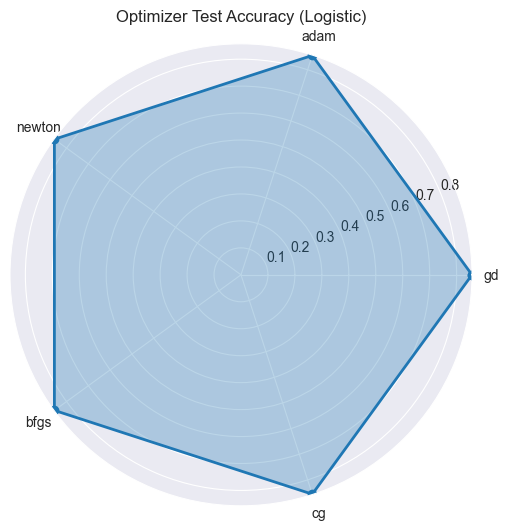

In [17]:
subset = results_df[results_df["Model"] == "logistic"]

labels = subset["Optimizer"].values
stats  = subset["Test_acc"].values

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
stats = np.concatenate((stats, [stats[0]]))
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

ax.plot(angles, stats, "o-", linewidth=2)
ax.fill(angles, stats, alpha=0.3)
ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
plt.title("Optimizer Test Accuracy (Logistic)")
plt.show()

In [18]:
results_df.sort_values(["Iterations", "Optimizer"])

,Model,Optimizer,Final_loss,Iterations,Train_acc,Test_acc,Runtime,History
7,ridge,newton,0.413004,5,0.850550,0.850856,0.001377,"[0.6931471785599453, 0.42140595066842546, 0.41..."
2,logistic,newton,0.376119,6,0.854218,0.855746,0.001605,"[0.6931471785599453, 0.3984932730789584, 0.377..."
8,ridge,bfgs,0.413004,9,0.850550,0.850856,0.001320,"[0.6931471785599453, 0.5809880183253068, 0.426..."
3,logistic,bfgs,0.376119,58,0.854218,0.855746,0.008997,"[0.6931471785599453, 0.569534416006646, 0.4027..."
9,ridge,cg,0.413004,89,0.850550,0.850856,0.012329,"[0.6931471785599453, 0.5809880183253068, 0.517..."
4,logistic,cg,0.376119,354,0.854218,0.855746,0.050210,"[0.6931471785599453, 0.569534416006646, 0.5035..."
1,logistic,adam,0.376119,1000,0.854218,0.855746,0.161581,"[0.685408036317412, 0.6784113025175069, 0.6720..."
6,ridge,adam,0.413004,1000,0.850550,0.850856,0.145253,"[0.6860580356607273, 0.6807151037215401, 0.676..."
0,logistic,gd,0.393087,1000,0.852384,0.856968,0.137563,"[0.6916914990364231, 0.6902447699937418, 0.688..."
5,ridge,gd,0.420941,1000,0.850550,0.850856,0.139075,"[0.691692644396655, 0.6902515399379457, 0.6888..."


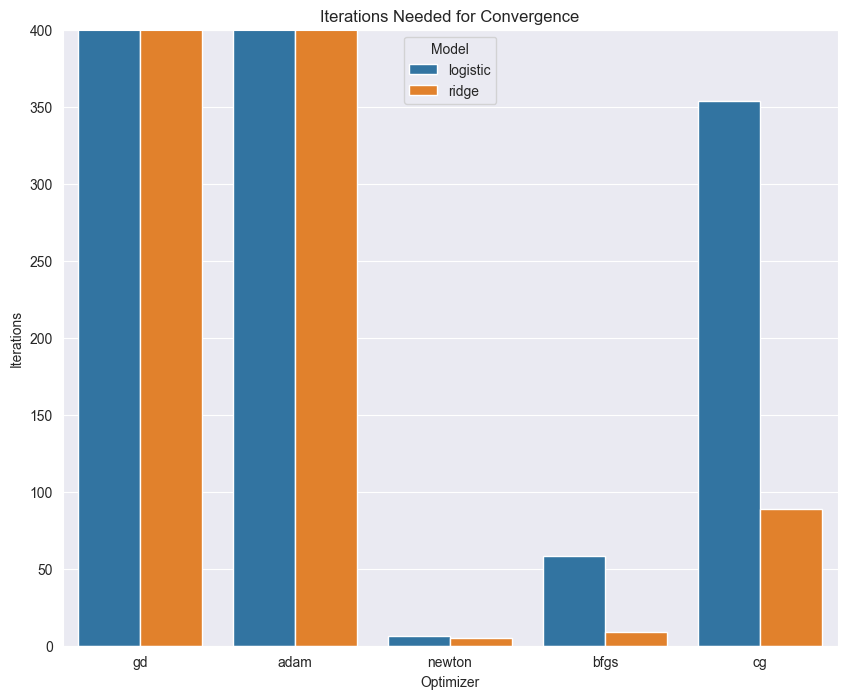

In [19]:
plt.figure(figsize=(10, 8))
sns.barplot(data=results_df, x="Optimizer", y="Iterations", hue="Model")
plt.title("Iterations Needed for Convergence")
plt.ylabel("Iterations")
plt.ylim(0, 400)
plt.show()

In [20]:
results_df.sort_values(["Final_loss", "Iterations", "Optimizer"])

,Model,Optimizer,Final_loss,Iterations,Train_acc,Test_acc,Runtime,History
2,logistic,newton,0.376119,6,0.854218,0.855746,0.001605,"[0.6931471785599453, 0.3984932730789584, 0.377..."
3,logistic,bfgs,0.376119,58,0.854218,0.855746,0.008997,"[0.6931471785599453, 0.569534416006646, 0.4027..."
4,logistic,cg,0.376119,354,0.854218,0.855746,0.050210,"[0.6931471785599453, 0.569534416006646, 0.5035..."
1,logistic,adam,0.376119,1000,0.854218,0.855746,0.161581,"[0.685408036317412, 0.6784113025175069, 0.6720..."
0,logistic,gd,0.393087,1000,0.852384,0.856968,0.137563,"[0.6916914990364231, 0.6902447699937418, 0.688..."
7,ridge,newton,0.413004,5,0.850550,0.850856,0.001377,"[0.6931471785599453, 0.42140595066842546, 0.41..."
6,ridge,adam,0.413004,1000,0.850550,0.850856,0.145253,"[0.6860580356607273, 0.6807151037215401, 0.676..."
8,ridge,bfgs,0.413004,9,0.850550,0.850856,0.001320,"[0.6931471785599453, 0.5809880183253068, 0.426..."
9,ridge,cg,0.413004,89,0.850550,0.850856,0.012329,"[0.6931471785599453, 0.5809880183253068, 0.517..."
5,ridge,gd,0.420941,1000,0.850550,0.850856,0.139075,"[0.691692644396655, 0.6902515399379457, 0.6888..."


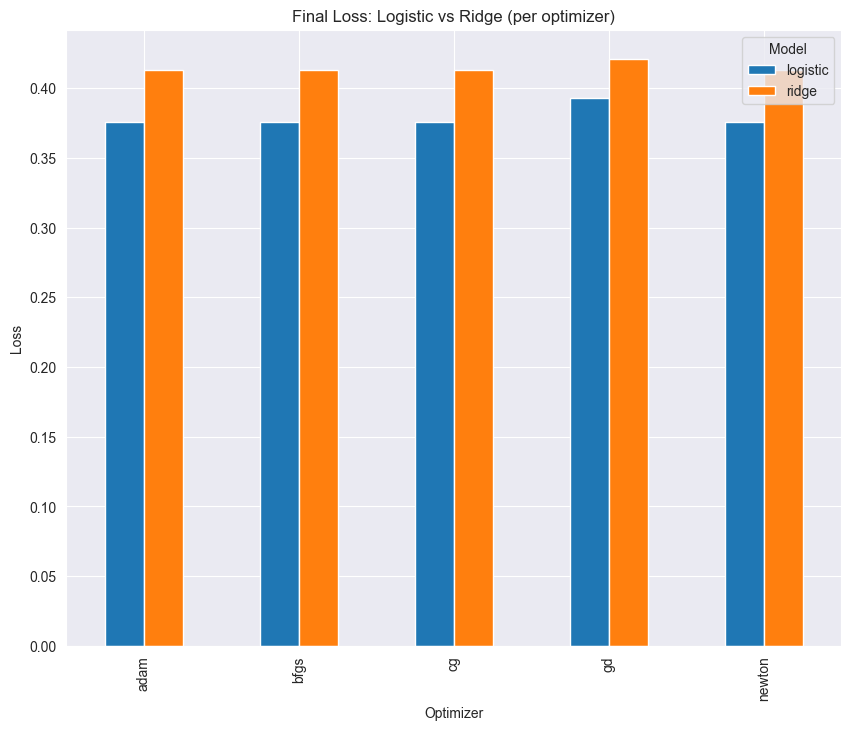

In [21]:
pivot = results_df.pivot(index="Optimizer", columns="Model", values="Final_loss")

pivot.plot(kind="bar", figsize=(10, 8))
plt.title("Final Loss: Logistic vs Ridge (per optimizer)")
plt.ylabel("Loss")
plt.show()

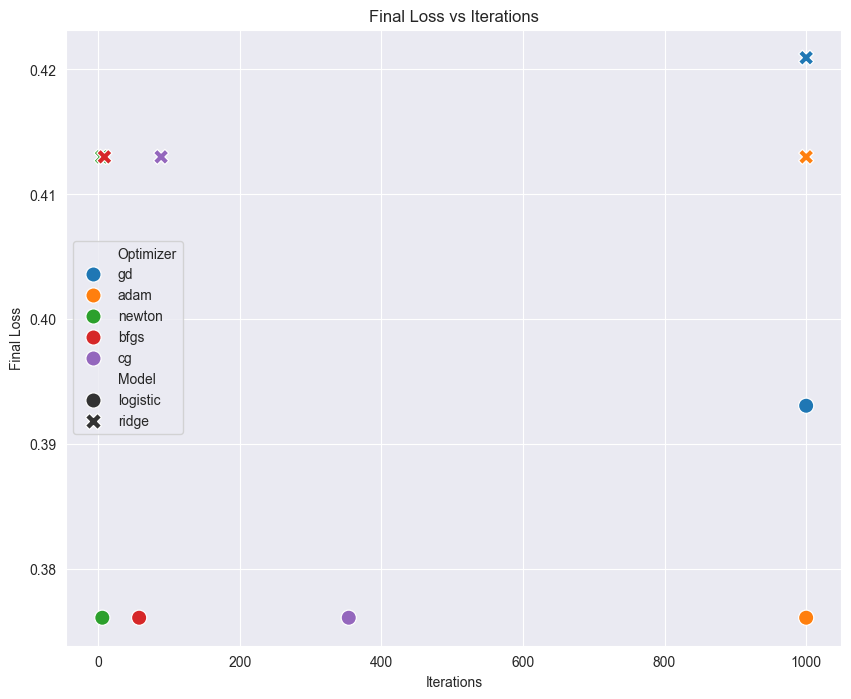

In [22]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=results_df, x="Iterations", y="Final_loss", hue="Optimizer", style="Model", s=120)
plt.title("Final Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Final Loss")
plt.show()


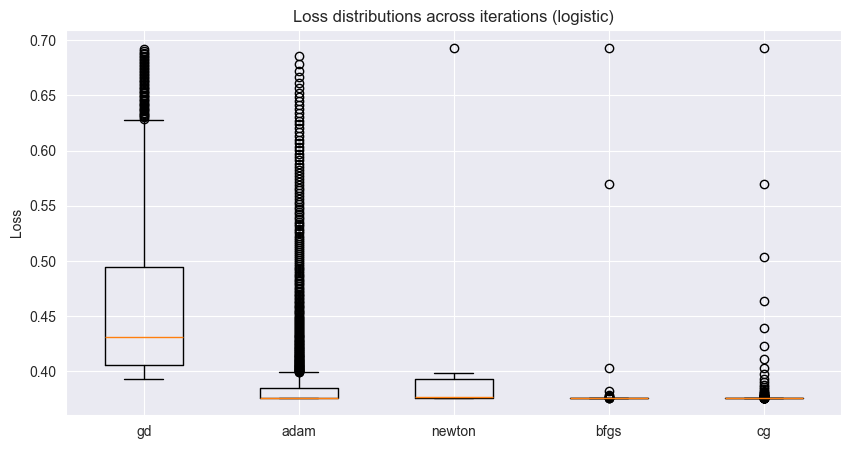

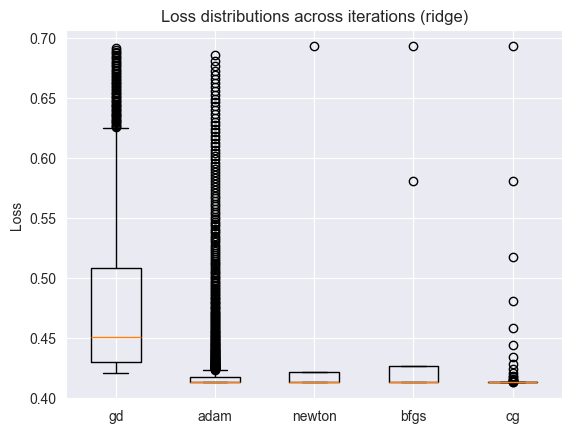

In [23]:
plt.figure(figsize=(10,5))

for model in ["logistic", "ridge"]:
    subset = results_df[results_df["Model"] == model]
    plt.boxplot(subset["History"], tick_labels=subset["Optimizer"])
    plt.title(f"Loss distributions across iterations ({model})")
    plt.ylabel("Loss")
    plt.show()


In [24]:
results_df.sort_values(["Runtime", "Iterations", "Optimizer"])

,Model,Optimizer,Final_loss,Iterations,Train_acc,Test_acc,Runtime,History
8,ridge,bfgs,0.413004,9,0.850550,0.850856,0.001320,"[0.6931471785599453, 0.5809880183253068, 0.426..."
7,ridge,newton,0.413004,5,0.850550,0.850856,0.001377,"[0.6931471785599453, 0.42140595066842546, 0.41..."
2,logistic,newton,0.376119,6,0.854218,0.855746,0.001605,"[0.6931471785599453, 0.3984932730789584, 0.377..."
3,logistic,bfgs,0.376119,58,0.854218,0.855746,0.008997,"[0.6931471785599453, 0.569534416006646, 0.4027..."
9,ridge,cg,0.413004,89,0.850550,0.850856,0.012329,"[0.6931471785599453, 0.5809880183253068, 0.517..."
4,logistic,cg,0.376119,354,0.854218,0.855746,0.050210,"[0.6931471785599453, 0.569534416006646, 0.5035..."
0,logistic,gd,0.393087,1000,0.852384,0.856968,0.137563,"[0.6916914990364231, 0.6902447699937418, 0.688..."
5,ridge,gd,0.420941,1000,0.850550,0.850856,0.139075,"[0.691692644396655, 0.6902515399379457, 0.6888..."
6,ridge,adam,0.413004,1000,0.850550,0.850856,0.145253,"[0.6860580356607273, 0.6807151037215401, 0.676..."
1,logistic,adam,0.376119,1000,0.854218,0.855746,0.161581,"[0.685408036317412, 0.6784113025175069, 0.6720..."


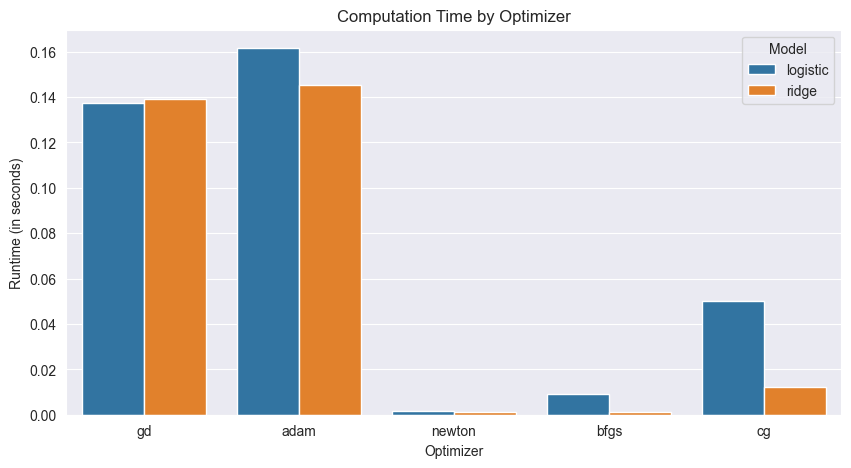

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Optimizer", y="Runtime", hue="Model")
plt.title("Computation Time by Optimizer")
plt.ylabel("Runtime (in seconds)")
plt.show()

## Hessian and Second-Order Structure of Logistic Regression

For logistic regression, the loss function is

$$
J(w) = -\frac{1}{n}\sum_{i=1}^{n}
\left[
y_i \log p_i + (1-y_i)\log(1-p_i)
\right],
\qquad
p_i = \sigma(x_i^\top w).
$$

### Gradient

Because $p_i = \sigma(x_i^\top w)$ and $\sigma'(z) = \sigma(z)(1-\sigma(z))$, the gradient is

$$
\nabla J(w)
= \frac{1}{n} X^\top (p - y),
$$

where $p$ is the vector of predicted probabilities.

### Hessian

The Hessian of logistic regression has the well-known form:

$$
H(w) = \frac{1}{n} X^\top D X,
$$

where
- $D$ is a diagonal matrix with
  $D_{ii} = p_i(1 - p_i)$
- $p_i(1-p_i)$ is always **positive**
- so $D$ is positive diagonal
- and therefore $H(w)$ is **positive semidefinite**.

This implies:

- The logistic loss is **convex**,
- Newton’s method has well-behaved updates,
- BFGS approximations converge rapidly because $H(w)$ has stable curvature.

### Interpretation of the Hessian

The diagonal element $p_i(1 - p_i)$ measures **uncertainty** of each prediction:

- Near 0.5 → large curvature → the model is uncertain
- Near 0 or 1 → small curvature → prediction confident → small contribution

Thus, the Hessian weights each row of $X$ by how uncertain the model is at $w$.

### Ridge Logistic Regression Hessian

For ridge logistic regression with penalty $\frac{\alpha}{2}\|w_{\text{no-bias}}\|^2$,
the Hessian becomes

$$
H_{\text{ridge}}(w)
= H_{\text{logistic}}(w)
+ \alpha I_{\text{no-bias}}
$$

where the identity matrix excludes the bias coordinate.

This shifts the eigenvalues of $H$ upward by $\alpha$, improving conditioning
and making Newton/BFGS even more stable.

### Role of the Hessian in Optimization

- **Gradient descent** ignores curvature → small steps in flat directions → slow.
- **Adam** rescales coordinates but still uses only first-order information.
- **Newton** uses $H^{-1}$ to reshape the loss landscape → nearly quadratic convergence.
- **BFGS** builds an approximation of $H^{-1}$ → fast but slightly slower than Newton.
- **Conjugate Gradient** builds directions orthogonal in the Hessian’s geometry.

The differences in iteration counts in our results (e.g., Newton solving logistic regression in ~6 iterations and solving ridge logistic regression in ~5 iterations) directly reflect the curvature encoded in the Hessian.

### Curvature and Eigenvalues

Because the Hessian has the form $H = X^\top D X / n$, its eigenvalues satisfy

$$
\lambda_{\min}(H) \ge 0, \qquad
\lambda_{\max}(H) = O(\|X\|^2).
$$

Poor conditioning (large ratio $\lambda_{\max} / \lambda_{\min}$) slows gradient descent but does not affect Newton’s method nearly as much, which explains the dramatic iteration differences observed in our experiments.


## Testing differing initial conditions

In [26]:
n_inits = 5   # number of different initial points per optimizer/model

init_results = []

for model_name in models:
    for opt_name in optimizers:
        for k in range(n_inits):
            # random initial condition
            w0 = np.random.randn(X_train.shape[1])

            res = run_optimizer(optimizer_name=opt_name, model_name=model_name, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, alpha=1.0,
                                iters=1000, lr=0.01, w0=w0)

            # record which init + how big it was
            res["Init_id"] = k
            res["Init_norm"] = np.linalg.norm(w0)
            init_results.append(res)

init_results_df = pd.DataFrame(init_results)
init_results_df


,Model,Optimizer,Final_loss,Iterations,Train_acc,Test_acc,Runtime,History,Init_id,Init_norm
0,logistic,gd,0.484017,1000,0.815403,0.822738,0.143376,"[1.5326959461074043, 1.5295810681917799, 1.526...",0,3.700465
1,logistic,gd,0.535661,1000,0.784230,0.788509,0.145661,"[1.539575531344898, 1.5370398043491191, 1.5345...",1,3.964292
2,logistic,gd,0.502708,1000,0.840770,0.839853,0.141137,"[0.9651689496156234, 0.963966767648192, 0.9627...",2,3.417925
3,logistic,gd,0.413593,1000,0.829156,0.833741,0.144947,"[1.007508043179163, 1.0052658036322453, 1.0030...",3,2.972455
4,logistic,gd,0.559080,1000,0.818765,0.828851,0.142713,"[1.1536071825380185, 1.152106062715957, 1.1506...",4,4.436049
5,logistic,adam,0.376119,1000,0.854218,0.855746,0.136047,"[0.6320635354896376, 0.6241114075137637, 0.616...",0,3.109731
6,logistic,adam,0.376119,1000,0.854218,0.855746,0.138132,"[1.3242269226998467, 1.3107565337165263, 1.297...",1,4.199286
7,logistic,adam,0.376120,1000,0.854218,0.855746,0.141222,"[1.6116407686569683, 1.599321755392687, 1.5870...",2,4.620925
8,logistic,adam,0.376122,1000,0.854218,0.855746,0.142706,"[1.2762508957871452, 1.2644993414045722, 1.253...",3,3.194916
9,logistic,adam,0.376164,1000,0.854523,0.856968,0.142515,"[1.8358637942891716, 1.8193264688723556, 1.802...",4,4.429152


In [27]:
init_results_df.groupby(["Model", "Optimizer"])["Iterations"].agg(["mean", "std"])

mean         std
Model    Optimizer                    
logistic adam       1000.0    0.000000
         bfgs         63.4    9.071935
         cg          420.2   34.751978
         gd         1000.0    0.000000
         newton     1000.0    0.000000
ridge    adam       1000.0    0.000000
         bfgs         11.2    0.447214
         cg           87.8    2.774887
         gd         1000.0    0.000000
         newton      403.6  544.436222

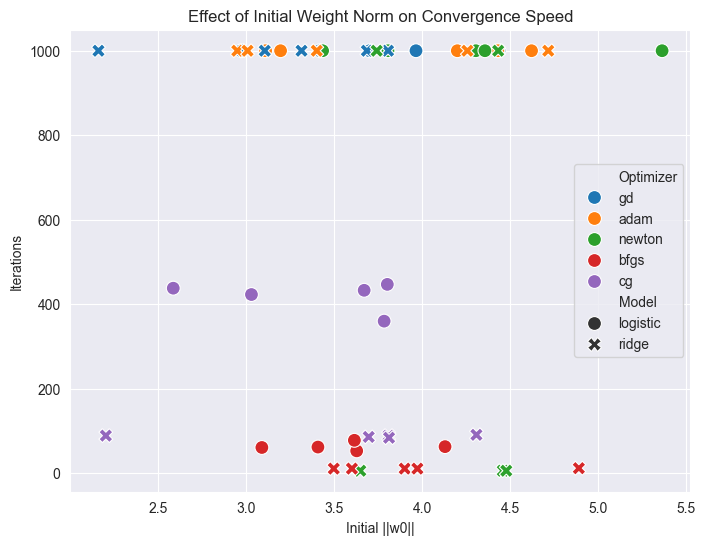

In [35]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=init_results_df, x="Init_norm", y="Iterations", hue="Optimizer", style="Model", s=100)
plt.title("Effect of Initial Weight Norm on Convergence Speed")
plt.xlabel("Initial ||w0||")
plt.ylabel("Iterations")
plt.show()


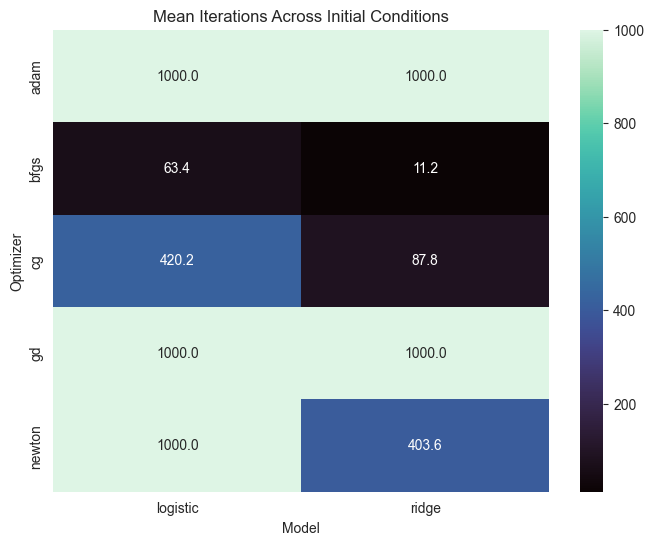

In [36]:
summary = (init_results_df.groupby(["Optimizer", "Model"])["Iterations"].mean().unstack("Model"))

plt.figure(figsize=(8,6))
sns.heatmap(summary, annot=True, fmt=".1f", cmap="mako")
plt.title("Mean Iterations Across Initial Conditions")
plt.ylabel("Optimizer")
plt.show()


## Level Sets

In [46]:
def gd_trajectory(w0, loss_fn, grad_fn, X, y, lr=0.05, iters=40):
    """Simple GD that records the entire path."""
    w = w0.copy()
    traj = [w.copy()]
    history = [loss_fn(w, X, y)]

    for _ in range(iters):
        g = grad_fn(w, X, y)
        w = w - lr * g
        traj.append(w.copy())
        history.append(loss_fn(w, X, y))

    return w, history, traj


def newton_trajectory(w0, loss_fn, grad_fn, hess_fn, X, y, iters=8):
    """Simple Newton method that records the entire path."""
    w = w0.copy()
    traj = [w.copy()]
    history = [loss_fn(w, X, y)]

    for _ in range(iters):
        g = grad_fn(w, X, y)
        H = hess_fn(w, X, y)

        # solve H p = g for the Newton step p
        try:
            step = np.linalg.solve(H, g)
        except np.linalg.LinAlgError:
            # if H is singular/ill-conditioned, break
            break

        w = w - step
        traj.append(w.copy())
        history.append(loss_fn(w, X, y))

    return w, history, traj


In [47]:
d = X_train.shape[1]

# pick a starting point (a bit away from optimum)
w0_traj = np.zeros(d)

w_gd, hist_gd, traj_gd = gd_trajectory(w0=w0_traj, loss_fn=logistic_loss, grad_fn=logistic_grad, X=X_train, y=y_train, lr=0.05, iters=40)

w_new, hist_new, traj_new = newton_trajectory(w0=w0_traj, loss_fn=logistic_loss, grad_fn=logistic_grad, hess_fn=logistic_hess, X=X_train, y=y_train, iters=8)

print("GD final loss:", hist_gd[-1])
print("Newton final loss:", hist_new[-1])


GD final loss: 0.5170658280462956
Newton final loss: 0.37611945949015807


In [41]:
# solve logistic once with Newton to get w_opt -> optimum point
d = X_train.shape[1]
w0 = np.zeros(d)

w_opt, hist_newton = newton(
    w0=w0,
    loss_fn=logistic_loss,
    grad_fn=logistic_grad,
    hess_fn=logistic_hess,
    X=X_train,
    y=y_train,
    iters=20,
)
print("Newton final loss:", hist_newton[-1])
print("w_opt[:5]:", w_opt[:5])


Newton final loss: 0.3761194594901581
w_opt[:5]: [0.30184984 0.55759674 0.0653768  0.19629583 0.05166893]


In [42]:
i, j = 0, 1

w1_vals = np.linspace(w_opt[i] - 2, w_opt[i] + 2, 100)
w2_vals = np.linspace(w_opt[j] - 2, w_opt[j] + 2, 100)

W1, W2 = np.meshgrid(w1_vals, w2_vals)
Z = np.zeros_like(W1)

# compute the loss at each grid point
for a in range(W1.shape[0]):
    for b in range(W1.shape[1]):
        w_temp = w_opt.copy()
        w_temp[i] = W1[a, b]
        w_temp[j] = W2[a, b]
        Z[a, b] = logistic_loss(w_temp, X_train, y_train)

print("Z min/max:", np.nanmin(Z), np.nanmax(Z))


Z min/max: 0.3761678374914586 0.8932087672590225


Text(0.5, 1.0, 'Level Sets of Logistic Loss in (w[i], w[j]) Plane')

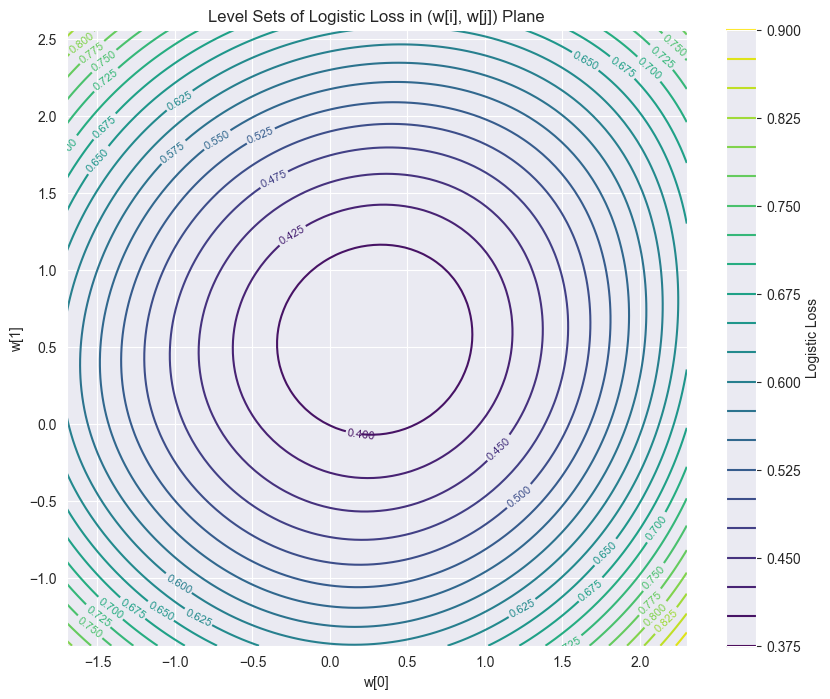

In [45]:
plt.figure(figsize=(10,8))
CS = plt.contour(W1, W2, Z, levels=20, cmap="viridis")
plt.clabel(CS, inline=True, fontsize=8)
plt.colorbar(label="Logistic Loss")
plt.xlabel(f"w[{i}]")
plt.ylabel(f"w[{j}]")
plt.title("Level Sets of Logistic Loss in (w[i], w[j]) Plane")


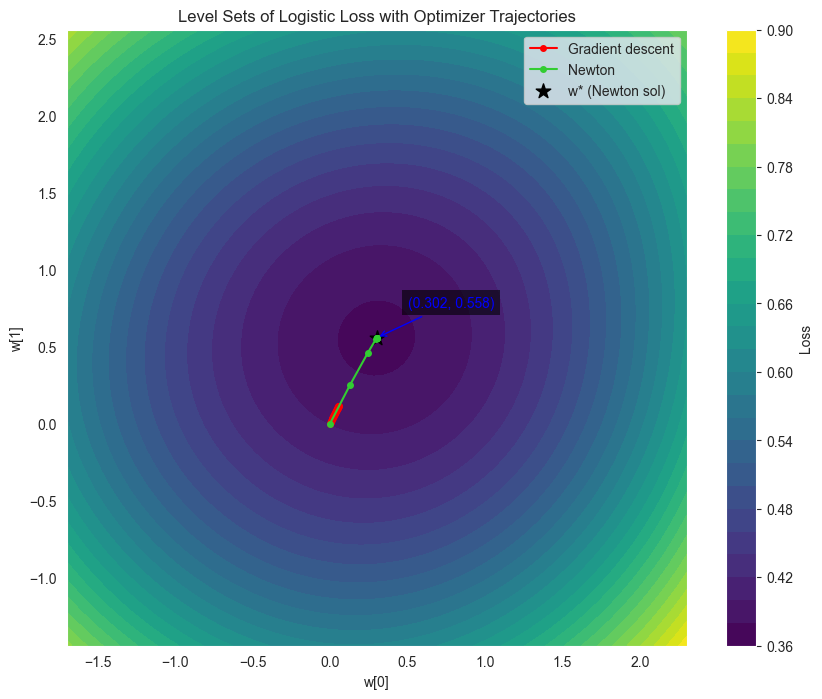

In [71]:
plt.figure(figsize=(10,8))

# contour lines
cont = plt.contourf(W1, W2, Z, levels=30, cmap="viridis")
plt.colorbar(cont, label="Loss")

# plot trajectories
def plot_traj(traj, label, color):
    xs = [w[i] for w in traj]
    ys = [w[j] for w in traj]
    plt.plot(xs, ys, marker="o", markersize=4, linewidth=1.5, label=label, color=color)

# overlay GD and Newton paths
plot_traj(traj_gd, "Gradient descent", "red")
plot_traj(traj_new, "Newton", "limegreen")

# optimum point
plt.scatter(w_opt[i], w_opt[j], color="black", marker="*", s=120, label="w* (Newton sol)")
# add annotation for the coordinate values
plt.annotate(f"({w_opt[i]:.3f}, {w_opt[j]:.3f})", xy=(w_opt[i], w_opt[j]), xytext=(w_opt[i] + 0.2, w_opt[j] + 0.2),
             fontsize=10, color="blue", bbox=dict(facecolor='black', alpha=0.6, edgecolor='none'), arrowprops=dict(arrowstyle='->', color='blue'))

plt.xlabel(f"w[{i}]")
plt.ylabel(f"w[{j}]")
plt.title("Level Sets of Logistic Loss with Optimizer Trajectories")
plt.legend()
plt.show()


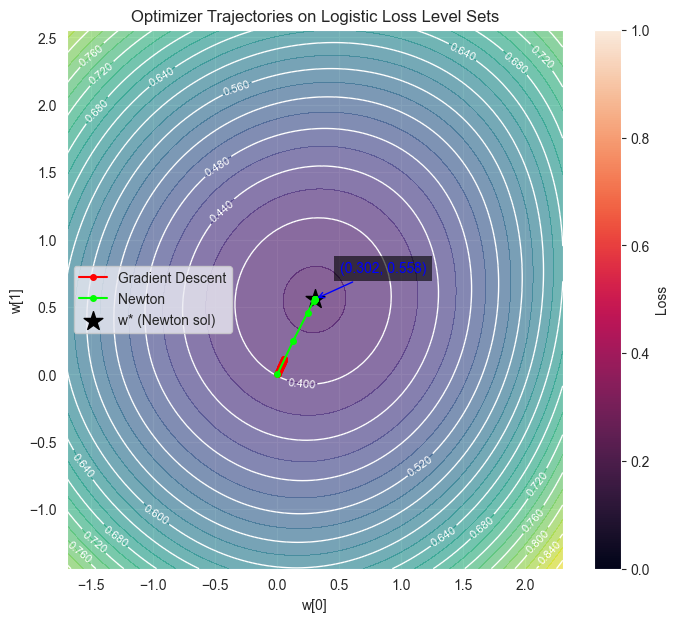

In [70]:
# combining plots
plt.figure(figsize=(8,7))

plt.contourf(W1, W2, Z, levels=30, cmap="viridis", alpha=0.6)

# contour lines
CS = plt.contour(W1, W2, Z, levels=15, colors="white", linewidths=1)
plt.clabel(CS, inline=True, fontsize=8, fmt="%.3f")

# plot trajectories
def plot_traj(traj, label, color):
    xs = [w[i] for w in traj]
    ys = [w[j] for w in traj]
    plt.plot(xs, ys, marker="o", markersize=4, linewidth=2, label=label, color=color)

plot_traj(traj_gd, "Gradient Descent", "red")
plot_traj(traj_new, "Newton", "lime")

# optimum point
plt.scatter(w_opt[i], w_opt[j], color="black", edgecolor="black",
            marker="*", s=200, label="w* (Newton sol)")

# add annotation for the coordinate values
plt.annotate(f"({w_opt[i]:.3f}, {w_opt[j]:.3f})", xy=(w_opt[i], w_opt[j]), xytext=(w_opt[i] + 0.2, w_opt[j] + 0.2),
             fontsize=10, color="blue", bbox=dict(facecolor='black', alpha=0.6, edgecolor='none'), arrowprops=dict(arrowstyle='->', color='blue'))

plt.xlabel(f"w[{i}]")
plt.ylabel(f"w[{j}]")
plt.title("Optimizer Trajectories on Logistic Loss Level Sets")
plt.legend()
plt.colorbar(label="Loss")
plt.show()
